In [1]:
!pip install lightgbm

import pandas as pd
import numpy as np
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import pickle
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_PATH = "/content/drive/MyDrive/MajorProject/CIC_IoT_2023/Full_Dataset"

train_path = f"{BASE_PATH}/augmented_train_data.csv" # Load GAN augmented data
test_path  = f"{BASE_PATH}/test_frozen.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (912851, 47)
Test shape: (259646, 47)


/tmp/ipykernel_555/2170244315.py:7: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df  = pd.read_csv(test_path)


## Data cleaning

In [ ]:
print(f"Shape of training data: {train_df.shape}")
print(f"Shape of test data: {test_df.shape}")

Shape of training data: (912851, 47)
Shape of test data: (259646, 47)


In [5]:
LABEL_COL = 'label'

train_df = train_df.dropna(subset=[LABEL_COL])
test_df = test_df.dropna(subset=[LABEL_COL])

print("Train shape after cleaning", train_df.shape)
print("Test shape after cleaning", test_df.shape)

Train shape after cleaning (912851, 47)
Test shape after cleaning (259645, 47)


In [6]:
test_df["Radius"] = pd.to_numeric(test_df["Radius"], errors="coerce")

### Split features and target

In [7]:
X_train = train_df.drop(columns=[LABEL_COL])
y_train = train_df[LABEL_COL]

X_test = test_df.drop(columns=[LABEL_COL])
y_test = test_df[LABEL_COL]

### Label encode

In [8]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Number of classes:", len(le.classes_))

Number of classes: 34


In [9]:
classes = np.unique(y_train_enc)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights_dict = dict(zip(classes, class_weights))

# assign weights per sample
train_weights = np.array([class_weights_dict[y] for y in y_train_enc])

print("Sample weights ready")

Sample weights ready


### Convert to LGBM dataset

In [10]:
train_data = lgb.Dataset(X_train, label=y_train_enc, weight=train_weights)
test_data  = lgb.Dataset(X_test, label=y_test_enc)

### Define LightGBM model

In [11]:
params = {
    "objective": "multiclass",
    "num_class": len(le.classes_),

    "metric": ["multi_logloss", "multi_error"],

    # 🚀 more powerful model
    "learning_rate": 0.05,
    "num_leaves": 100,          # ↑ more capacity
    "max_depth": -1,
    "min_data_in_leaf": 20,     # allows minority learning

    # 🎯 focus on minority classes indirectly
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 5,

    # 🔥 regularization but not too strong
    "lambda_l1": 0.2,
    "lambda_l2": 0.2,

    "verbosity": -1,
    "seed": 42
}

### Train the Model

In [12]:
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,   
    valid_sets=[test_data],
    valid_names=["test"],
    callbacks=[
        lgb.log_evaluation(10),
        lgb.early_stopping(80)   
    ]
)

Training until validation scores don't improve for 80 rounds
[10]	test's multi_logloss: 0.954844	test's multi_error: 0.115331
[20]	test's multi_logloss: 0.5676	test's multi_error: 0.111009
[30]	test's multi_logloss: 0.416896	test's multi_error: 0.107851
[40]	test's multi_logloss: 0.350198	test's multi_error: 0.105309
[50]	test's multi_logloss: 0.318047	test's multi_error: 0.103056
[60]	test's multi_logloss: 0.300949	test's multi_error: 0.10125
[70]	test's multi_logloss: 0.290445	test's multi_error: 0.099636
[80]	test's multi_logloss: 0.283142	test's multi_error: 0.0980955
[90]	test's multi_logloss: 0.27768	test's multi_error: 0.0967128
[100]	test's multi_logloss: 0.27341	test's multi_error: 0.0955073
[110]	test's multi_logloss: 0.269502	test's multi_error: 0.0942826
[120]	test's multi_logloss: 0.266252	test's multi_error: 0.0931926
[130]	test's multi_logloss: 0.263606	test's multi_error: 0.0924339
[140]	test's multi_logloss: 0.261029	test's multi_error: 0.0916444
[150]	test's multi_log

### Predictions

In [13]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

### Evaluation

In [14]:
print("Accuracy:", accuracy_score(y_test_enc, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.9212039515492306

Classification Report:

                         precision    recall  f1-score   support

       Backdoor_Malware       0.54      0.56      0.55       638
          BenignTraffic       0.67      0.86      0.75      6000
       BrowserHijacking       0.61      0.70      0.65      1167
       CommandInjection       0.43      0.51      0.46      1078
 DDoS-ACK_Fragmentation       1.00      1.00      1.00      7799
        DDoS-HTTP_Flood       1.00      1.00      1.00      5742
        DDoS-ICMP_Flood       1.00      1.00      1.00      6000
DDoS-ICMP_Fragmentation       1.00      1.00      1.00      7655
      DDoS-PSHACK_Flood       1.00      1.00      1.00      6000
       DDoS-RSTFINFlood       1.00      1.00      1.00      6000
         DDoS-SYN_Flood       1.00      1.00      1.00      6000
         DDoS-SlowLoris       1.00      1.00      1.00      4672
DDoS-SynonymousIP_Flood       1.00      1.00      1.00      6000
         DDoS-TCP_Flood       1.00 

<Figure size 1000x1000 with 0 Axes>

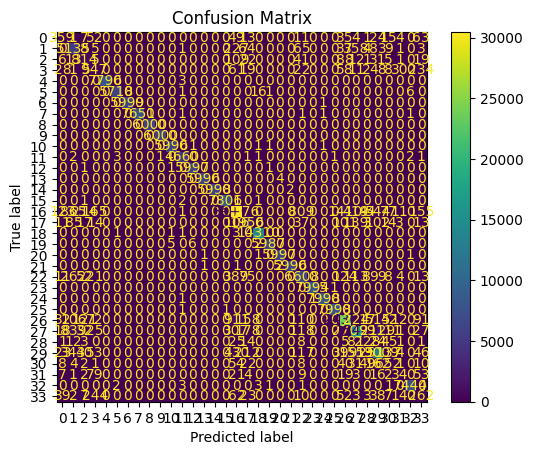

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

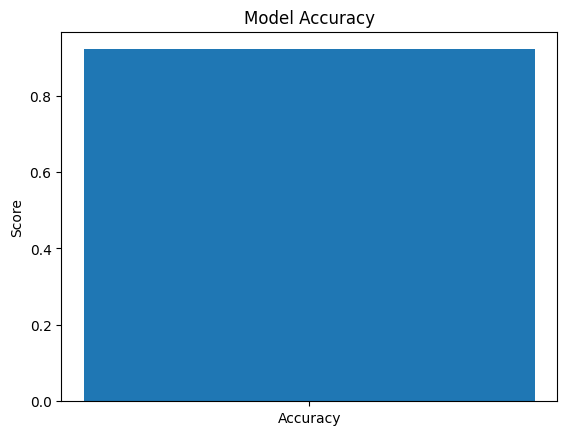

In [16]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_enc, y_pred)

plt.figure()
plt.bar(["Accuracy"], [acc])
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

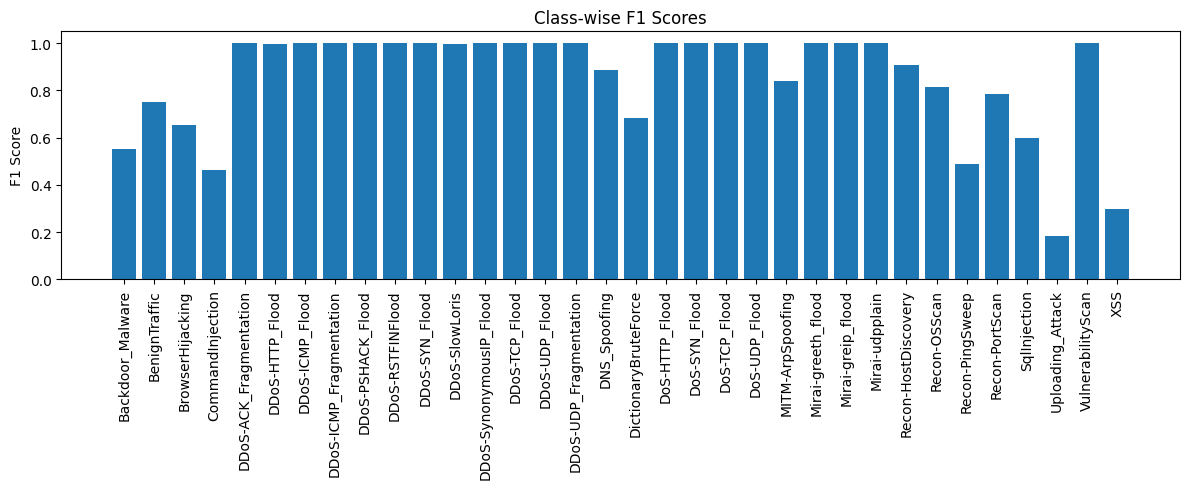

In [17]:

report = classification_report(y_test_enc, y_pred, target_names=le.classes_, output_dict=True)

class_names = []
f1_scores = []

for cls in le.classes_:
    class_names.append(cls)
    f1_scores.append(report[cls]["f1-score"])

plt.figure(figsize=(12, 5))
plt.bar(range(len(f1_scores)), f1_scores)

plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.ylabel("F1 Score")
plt.title("Class-wise F1 Scores")

plt.tight_layout()
plt.show()

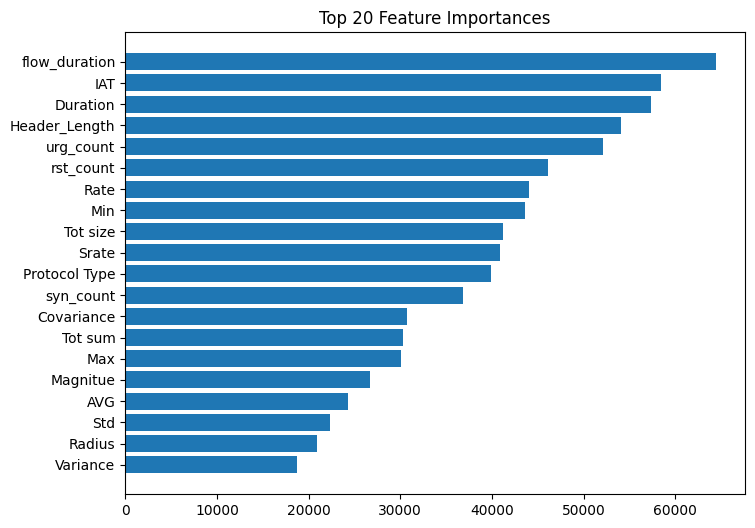

In [18]:
importance = model.feature_importance()
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(8, 6))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

## Save the Model

In [19]:
SAVE_DIR = "/content/drive/MyDrive/MajorProject/ModelB_LGBM"

os.makedirs(SAVE_DIR, exist_ok=True)

model.save_model(os.path.join(SAVE_DIR, "lgbm_augmented_model.txt"))

np.save(os.path.join(SAVE_DIR, "y_pred_aug.npy"), y_pred)
np.save(os.path.join(SAVE_DIR, "y_pred_probs_aug.npy"), y_pred_probs)

with open(os.path.join(SAVE_DIR, "label_encoder_aug.pkl"), "wb") as f:
    pickle.dump(le, f)

X_test.to_csv(os.path.join(SAVE_DIR, "X_test_aug.csv"), index=False)
y_test.to_csv(os.path.join(SAVE_DIR, "y_test_aug.csv"), index=False)

print("✅ Augmented model artifacts saved")

✅ Augmented model artifacts saved
